In [22]:
# Cluster 0: Moderate Income, Moderate Spending → Regular customers
# Cluster 1: High Income, High Spending → Premium customers
# Cluster 2: Low Income, High Spending → Promotional shoppers
# Cluster 3: High Income, Low Spending → Careful or Conservative customers
# Cluster 4: Low Income, Low Spending → Budget-conscious customers

In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
data=pd.read_csv("Mall_Customers.csv")

In [3]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
data.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


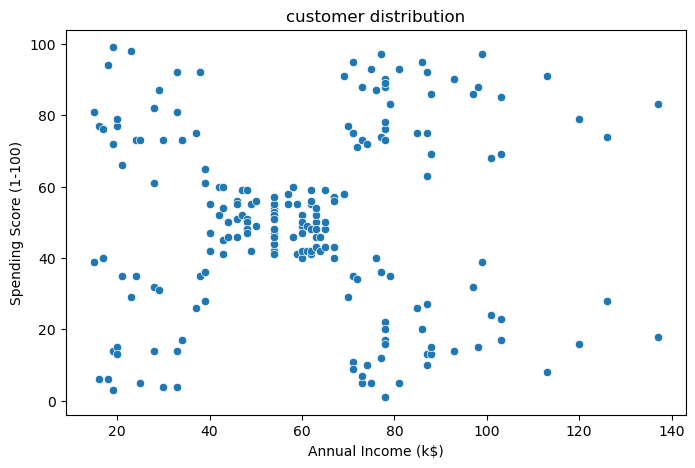

In [6]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=data,
    x='Annual Income (k$)',
    y='Spending Score (1-100)'
)
plt.title('customer distribution')
plt.show()

In [7]:
#pick the best attributes which contributes the more:
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
#now pick up the best number of clusters using the elbow method:
wcss = []
for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X_scaled)
    wcss.append(model.inertia_)

C:\Users\Victus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Victus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Victus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Victus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

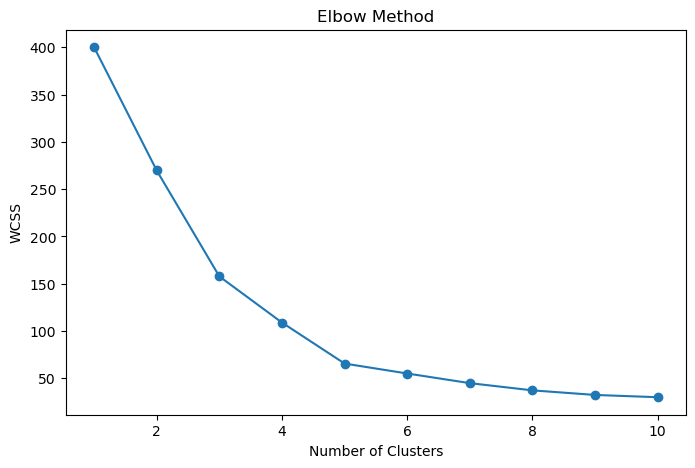

In [10]:
#plot the figure to see the best value of k
plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), wcss, marker='o')

plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')

plt.show()
# as from the figure the number of clusters best we can take is 5

In [12]:
#now apply the kmeans
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)
clusters = kmeans.fit_predict(X_scaled)

C:\Users\Victus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [13]:
#add column of clusters to the dataset
data['Cluster'] = clusters

In [14]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [15]:
data.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
195,196,Female,35,120,79,1
196,197,Female,45,126,28,3
197,198,Male,32,126,74,1
198,199,Male,32,137,18,3
199,200,Male,30,137,83,1


In [17]:
data["Cluster"].unique()

array([4, 2, 0, 1, 3], dtype=int32)

In [18]:
#save the result in another csv file means customer data with their cluster distribution:
data.to_csv("customer_segmentation_result.csv", index=False)

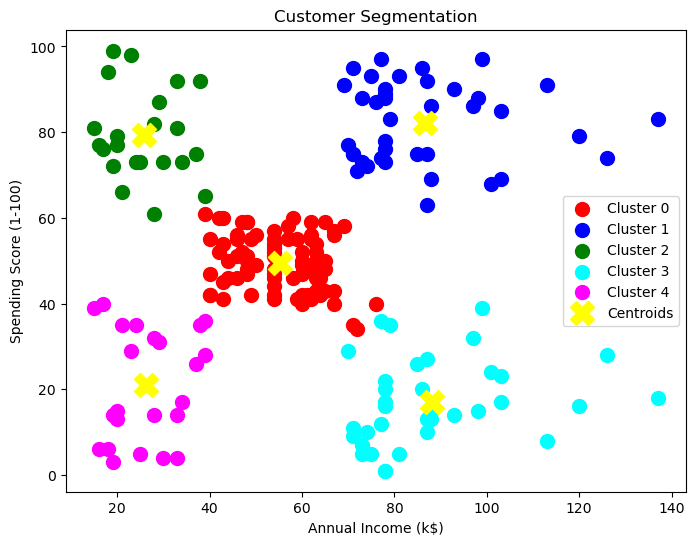

In [19]:
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.figure(figsize=(8,6))

plt.scatter(
    data.iloc[clusters == 0, 3],
    data.iloc[clusters == 0, 4],
    s=100,
    c='red',
    label='Cluster 0'
)

plt.scatter(
    data.iloc[clusters == 1, 3],
    data.iloc[clusters == 1, 4],
    s=100,
    c='blue',
    label='Cluster 1'
)

plt.scatter(
    data.iloc[clusters == 2, 3],
    data.iloc[clusters == 2, 4],
    s=100,
    c='green',
    label='Cluster 2'
)

plt.scatter(
    data.iloc[clusters == 3, 3],
    data.iloc[clusters == 3, 4],
    s=100,
    c='cyan',
    label='Cluster 3'
)

plt.scatter(
    data.iloc[clusters == 4, 3],
    data.iloc[clusters == 4, 4],
    s=100,
    c='magenta',
    label='Cluster 4'
)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    s=300,
    c='yellow',
    marker='X',
    label='Centroids'
)

plt.title("Customer Segmentation")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()

plt.show()